# MN logs stage: test accuracy vs reconstruction loss

This notebook analyzes the MN task only. Each `recons_key` is shown as one subplot, with points colored from light to dark in stage order and Pearson/Spearman correlation statistics written on the plot.

In [1]:
%matplotlib inline

from pathlib import Path
import warnings

from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy import stats
import torch

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
})

In [2]:
# -------------------- Config --------------------
TASK_LOG_PATH = Path("/data/dn/FRTP_revision1/imagecls/logs_stage/mn_simplecnnv2_relu_1e-05lr.pt")
TASK_NAME = TASK_LOG_PATH.stem.split('_')[0]
# Use "test" for test_recons_loss_list, or "train" for train_recons_loss_list.
LOSS_SOURCE = "train"
RECONS_METRICS = "relative_diff"  # ("relative_diff", "absolute_diff", "forward_norm")
# Set to True if stage 0 is a warmup/baseline point that should not enter statistics.
DROP_FIRST_STAGE = True

FIG_PATH = f"/data/dn/FRTP_revision1/imagecls/logs_stage/{TASK_NAME}_{LOSS_SOURCE}_{RECONS_METRICS}.png"
CSV_PATH = f"/data/dn/FRTP_revision1/imagecls/logs_stage/{TASK_NAME}_{LOSS_SOURCE}_{RECONS_METRICS}_stats.csv"
TASK_LOG_PATH

PosixPath('/data/dn/FRTP_revision1/imagecls/logs_stage/mn_simplecnnv2_relu_1e-05lr.pt')

In [3]:
def as_float_array(values):
    return np.asarray(values, dtype=float)


def p_text(pvalue):
    if not np.isfinite(pvalue):
        return "nan"
    if pvalue < 1e-4:
        return f"{pvalue:.1e}"
    return f"{pvalue:.4f}"


def stage_cmap():
    base = plt.get_cmap("Blues")
    return plt.matplotlib.colors.LinearSegmentedColormap.from_list(
        "stage_blues", base(np.linspace(0.35, 0.95, 256))
    )


def stage_norm(n):
    return plt.Normalize(vmin=0, vmax=max(n - 1, 1))


def stage_colors(n):
    if n <= 0:
        return []
    return stage_cmap()(stage_norm(n)(np.arange(n)))


def add_stage_colorbar(fig, max_points, rect=(0.91, 0.18, 0.018, 0.64), endpoint_labels=False, fontsize=10):
    mappable = plt.cm.ScalarMappable(norm=stage_norm(max_points), cmap=stage_cmap())
    mappable.set_array([])
    cax = fig.add_axes(rect)
    cbar = fig.colorbar(mappable, cax=cax)
    # cbar.set_label("Stage order")
    if endpoint_labels:
        cbar.set_ticks([])
        cbar.ax.text(0.5, -0.03, "early", transform=cbar.ax.transAxes, ha="center", va="top", fontsize=fontsize)
        cbar.ax.text(0.5, 1.03, "late", transform=cbar.ax.transAxes, ha="center", va="bottom", fontsize=fontsize)
    else:
        cbar.set_ticks([0, max(max_points - 1, 1)])
        cbar.set_ticklabels(["early", "late"])

def paired_xy(log, recons_key, RECONS_METRICS):
    x = as_float_array(log["test_score_list"])
    y = as_float_array(log[f"{LOSS_SOURCE}_recons_loss_list"][recons_key][RECONS_METRICS])
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    if DROP_FIRST_STAGE:
        x, y = x[1:], y[1:]
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def correlation_stats(x, y):
    n = len(x)
    if n < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return {
            "n": n,
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
        }

    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)
    return {
        "n": n,
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
    }


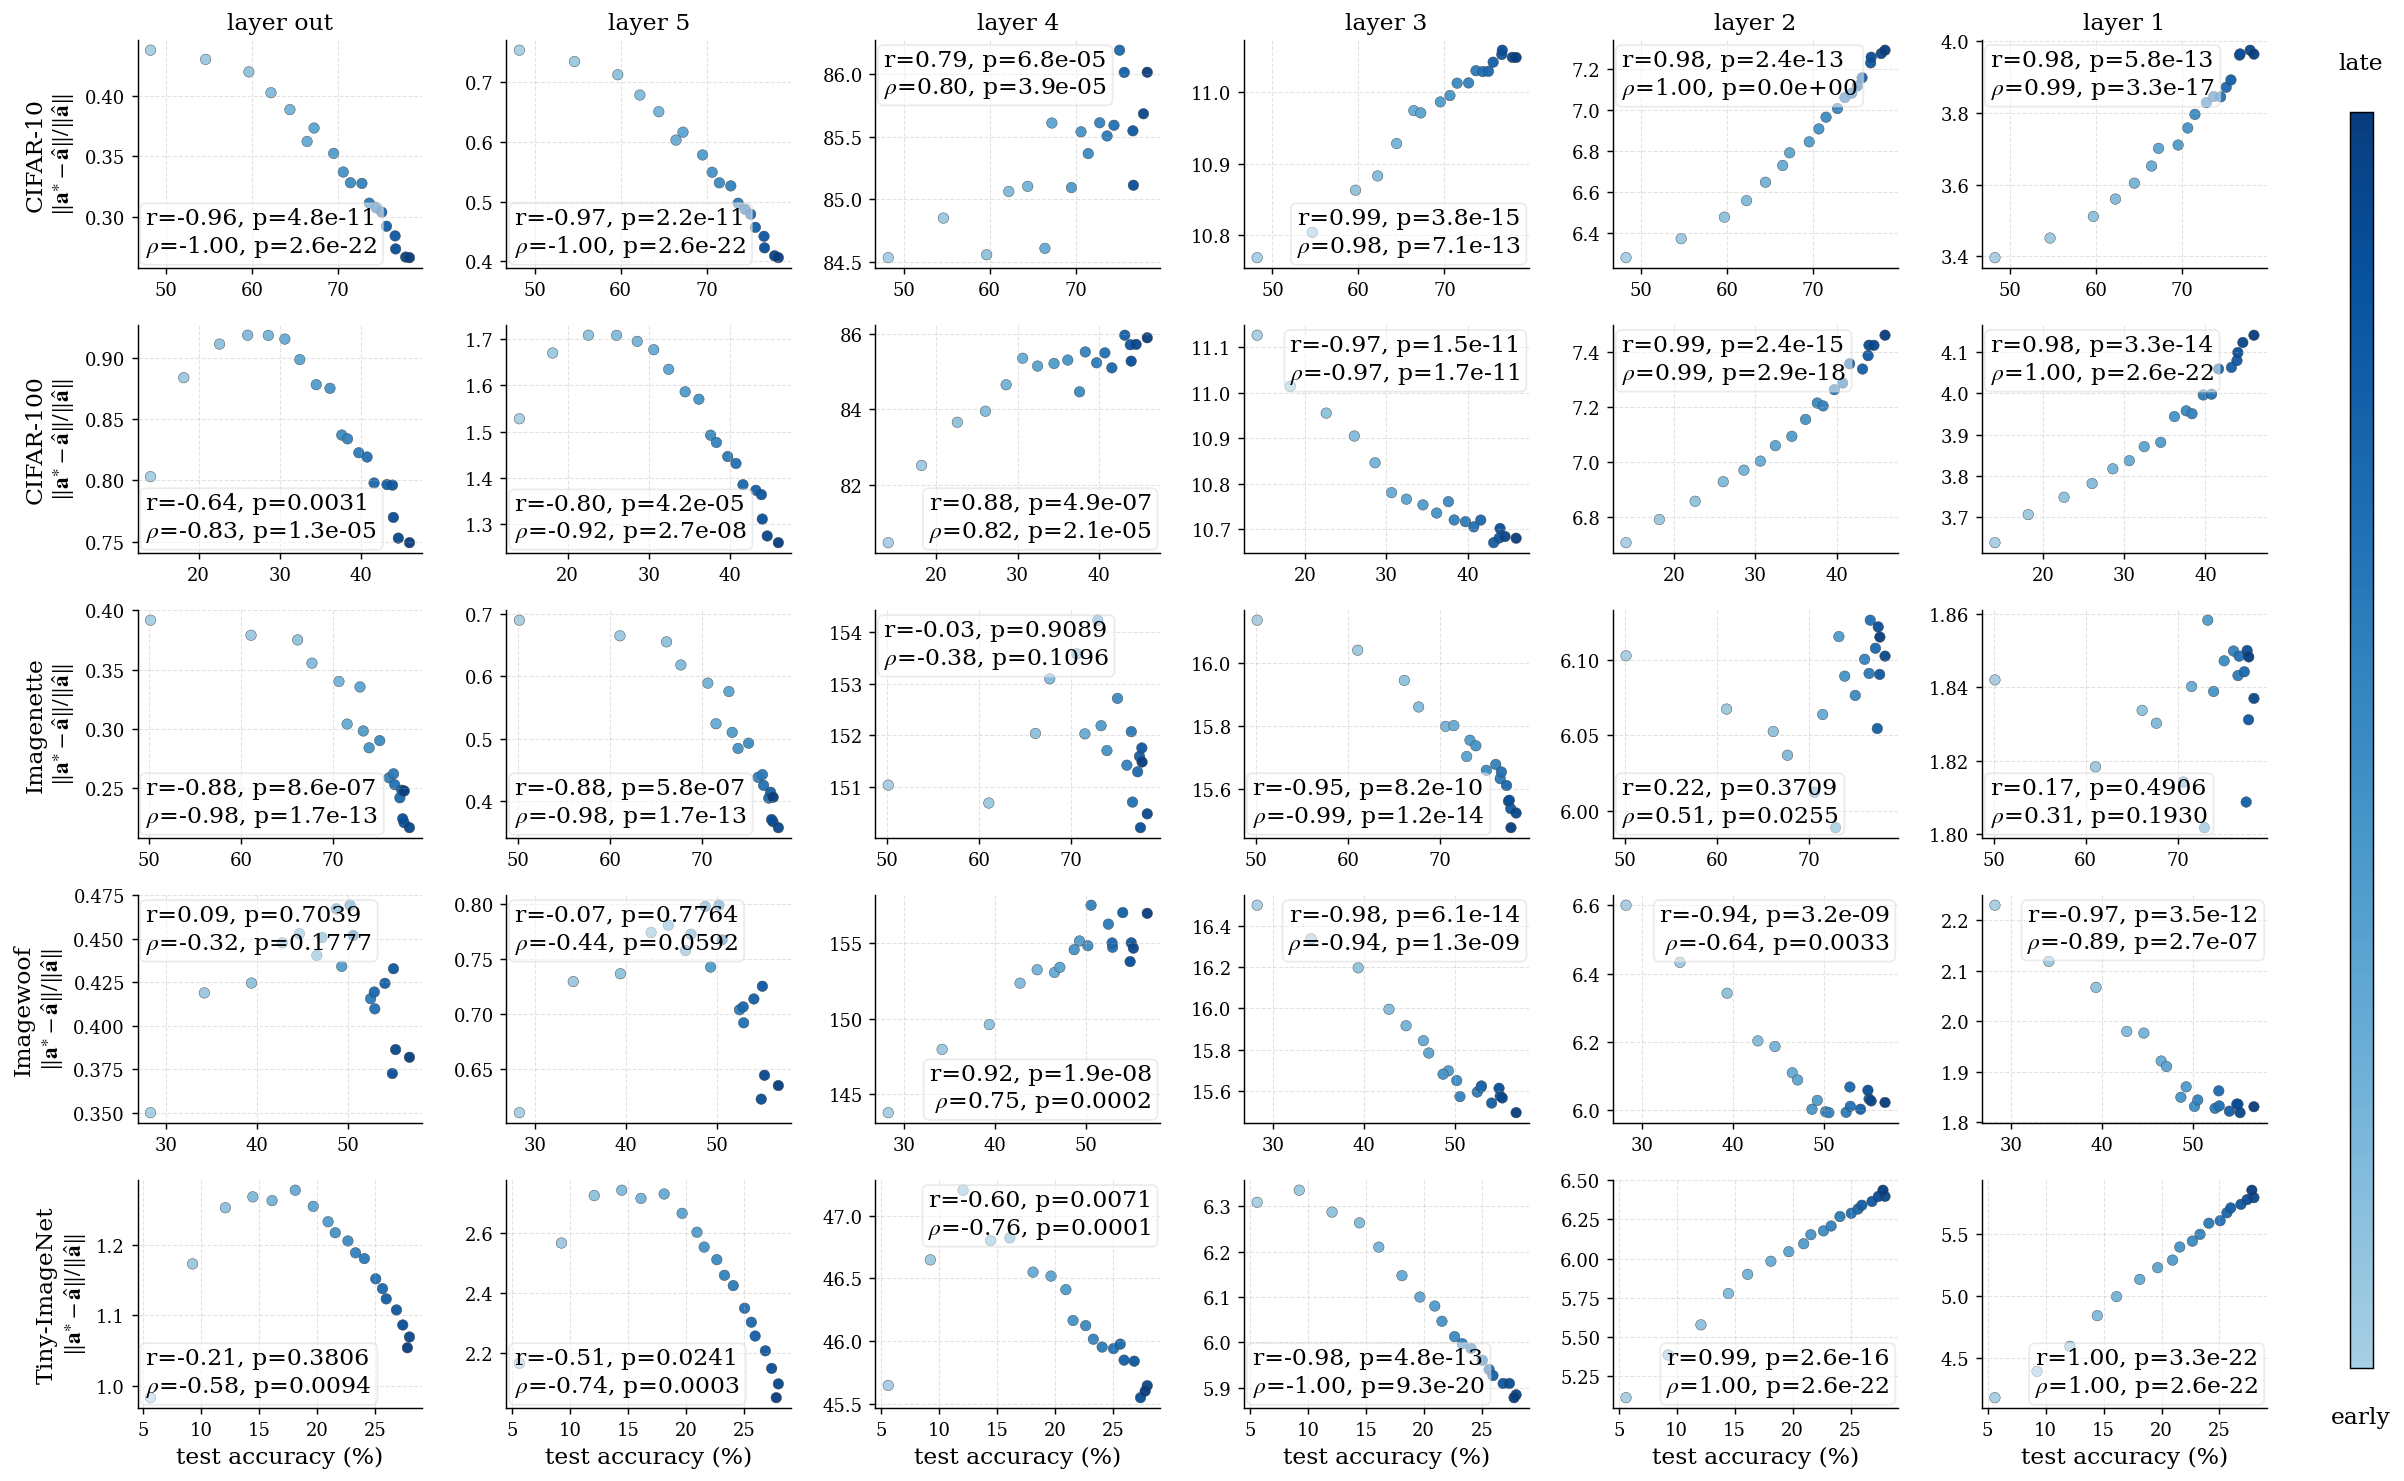

In [ ]:
# Plot all tasks at once: one row per task, one column per available recons_key.
LOGS_STAGE_DIR = Path("/data/dn/FRTP_revision1/imagecls/logs_stage")
# ALL_TASK_LOG_PATHS = [
#     LOGS_STAGE_DIR / "mn_simplecnnv2_relu_1e-05lr.pt",
#     LOGS_STAGE_DIR / "ci10_simplecnnv2_relu_1e-05lr.pt",
#     LOGS_STAGE_DIR / "ci100_simplecnnv2_relu_1e-05lr.pt",
#     LOGS_STAGE_DIR / "nette_simplecnnv2_relu_1e-05lr.pt",
#     LOGS_STAGE_DIR / "woof_simplecnnv2_relu_1e-05lr.pt",
#     LOGS_STAGE_DIR / "tin_simplecnnv2_relu_1e-05lr.pt",
# ]

ALL_TASK_LOG_PATHS = [
    # LOGS_STAGE_DIR / "mn_simplecnnv2_relu_1e-05lr.pt",
    LOGS_STAGE_DIR / "ci10_resnet18_1e-05lr.pt",
    LOGS_STAGE_DIR / "ci100_resnet18_1e-05lr.pt",
    LOGS_STAGE_DIR / "nette_resnet18_1e-05lr.pt",
    LOGS_STAGE_DIR / "woof_resnet18_1e-05lr.pt",
    LOGS_STAGE_DIR / "tin_resnet34_1e-05lr.pt",
]

LOSS_SOURCE = "train"
RECONS_METRICS = "absolute_diff"  # ("relative_diff", "absolute_diff", "forward_norm")
DROP_FIRST_STAGE = True

FIG_PATH =  f"all_tasks_all_recons_{LOSS_SOURCE}_{RECONS_METRICS}.pdf"
CSV_PATH = f"all_tasks_all_recons_{LOSS_SOURCE}_{RECONS_METRICS}_stats.csv"

# all_sub_title = {
#     "mn": {"recons_out": "final layer", "recons_z2": "layer 2", "recons_z1": "layer 1"},
#     "ci10": {"recons_out": "final layer", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
#     "ci100": {"recons_out": "final layer", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
#     "woof": {"recons_out": "final layer", "recons_z6": "layer 6", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
#     "nette": {"recons_out": "final layer", "recons_z6": "layer 6", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
#     "tin": {"recons_out": "final layer", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
# }

all_sub_title = {
    # "mn": {"recons_out": "final layer", "recons_z2": "layer 2", "recons_z1": "layer 1"},
    "ci10": {"recons_out": "layer out", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
    "ci100": {"recons_out": "layer out", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
    "woof": {"recons_out": "layer out", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
    "nette": {"recons_out": "layer out", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
    "tin": {"recons_out": "layer out", "recons_z5": "layer 5", "recons_z4": "layer 4", "recons_z3": "layer 3", "recons_z2": "layer 2", "recons_z1": "layer 1"},
}

task_names = {'mn':'MNIST', 'ci10':'CIFAR-10', 'ci100':'CIFAR-100', "nette":"Imagenette", "woof":"Imagewoof", "tin":"Tiny-ImageNet"}
task_infos = []
for task_log_path in ALL_TASK_LOG_PATHS:
    task_name = task_log_path.stem.split("_")[0]
    log = torch.load(task_log_path, map_location="cpu")
    recons_keys = list(log.get("recons_keys", log[f"{LOSS_SOURCE}_recons_loss_list"].keys()))
    task_infos.append({
        "task_name": task_name,
        "task_log_path": task_log_path,
        "log": log,
        "model": str(log.get("model", task_log_path.stem)),
        "recons_keys": recons_keys,
    })

nrows = len(task_infos)
ncols = max(len(info["recons_keys"]) for info in task_infos)-1
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3.25 * ncols, 2.3 * nrows),
    squeeze=False,
    sharex=False,
    sharey=False,
)

rows = []
max_points = 0

def empty_corner(x, y):
    if len(x) == 0:
        return 0.03, 0.04, "left", "bottom"
    xn = (x - np.min(x)) / max(np.ptp(x), 1e-12)
    yn = (y - np.min(y)) / max(np.ptp(y), 1e-12)
    corners = [(0.03, 0.04, "left", "bottom"), (0.03, 0.96, "left", "top"), (0.97, 0.04, "right", "bottom"), (0.97, 0.96, "right", "top")]
    scores = [np.exp(-(((xn - cx) / 0.40) ** 2 + ((yn - cy) / 0.28) ** 2)).sum() for cx, cy, _, _ in corners]
    return corners[int(np.argmin(scores))]

for row_idx, info in enumerate(task_infos):
    task_name = info["task_name"]
    recons_keys = info["recons_keys"]
    sub_title = all_sub_title.get(task_name, {})

    for col_idx in range(ncols):
        ax = axes[row_idx, col_idx]
        if col_idx >= len(recons_keys):
            ax.axis("off")
            continue

        recons_key = recons_keys[col_idx]
        if recons_key == 'recons_z0': continue
        x, y = paired_xy(info["log"], recons_key, RECONS_METRICS)
        max_points = max(max_points, len(x))
        x = x * 100
        st = correlation_stats(x, y)
        rows.append({
            "task": task_name,
            "model": info["model"],
            "log_path": str(info["task_log_path"]),
            "loss_source": LOSS_SOURCE,
            "recons_key": recons_key,
            "metrics": RECONS_METRICS,
            "drop_first_stage": DROP_FIRST_STAGE,
            **st,
        })

        ax.scatter(
            x,
            y,
            s=34,
            alpha=0.95,
            color=stage_colors(len(x)),
            edgecolor="0.25",
            linewidth=0.25,
        )
        if row_idx == 0:
            ax.set_title(sub_title.get(recons_key, recons_key), fontsize=13)
        if row_idx == nrows - 1:
            ax.set_xlabel("test accuracy (%)", fontsize=13)
        if col_idx == 0:
            # ax.set_ylabel(f"{task_names.get(task_name, task_name)}\n" + RECONS_METRICS, fontsize=12)
            ax.set_ylabel(f"{task_names.get(task_name, task_name)}\n" + r"$\|\mathbf{a}^{\ast}-\hat{\mathbf{a}}\|/\|\hat{\mathbf{a}}\|$", fontsize=13)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

        stat_text = (
            f"r={st['pearson_r']:.2f}, p={p_text(st['pearson_p'])}\n"
            rf"$\rho$={st['spearman_rho']:.2f}, p={p_text(st['spearman_p'])}"
        )
        tx, ty, ha, va = empty_corner(x, y)
        ax.text(
            tx,
            ty,
            stat_text,
            transform=ax.transAxes,
            va=va,
            ha=ha,
            fontsize=13,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.5, "edgecolor": "0.85"},
        )

fig.tight_layout(rect=[0, 0, 0.90, 1])
if max_points:
    add_stage_colorbar(fig, max_points, rect=(0.925, 0.08, 0.009, 0.84), endpoint_labels=True, fontsize=13)

stats_df = pd.DataFrame(rows)
fig.savefig(FIG_PATH, bbox_inches="tight")
stats_df.to_csv(CSV_PATH, index=False)
plt.show()
# display(stats_df)

In [8]:
summary_cols = [
    "recons_key",
    "n",
    "pearson_r",
    "pearson_p",
    "spearman_rho",
    "spearman_p",
]

summary = stats_df[summary_cols].copy()
for col in summary.select_dtypes(include=[float]).columns:
    summary[col] = summary[col].map(lambda v: np.nan if pd.isna(v) else float(f"{v:.6g}"))

display(Markdown(f"MN task, `{LOSS_SOURCE}_recons_loss`, DROP_FIRST_STAGE={DROP_FIRST_STAGE}."))
display(summary)


MN task, `train_recons_loss`, DROP_FIRST_STAGE=True.

,recons_key,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,recons_out,19,-0.947443,7.709290e-10,-0.989474,1.030540e-15
1,recons_z4,19,-0.967429,1.413600e-11,-1.000000,0.000000e+00
2,recons_z3,19,-0.890946,3.136390e-07,-1.000000,0.000000e+00
3,recons_z2,19,0.968292,1.128670e-11,0.608772,5.671630e-03
4,recons_z1,19,0.985676,1.395220e-14,0.991228,2.200850e-16


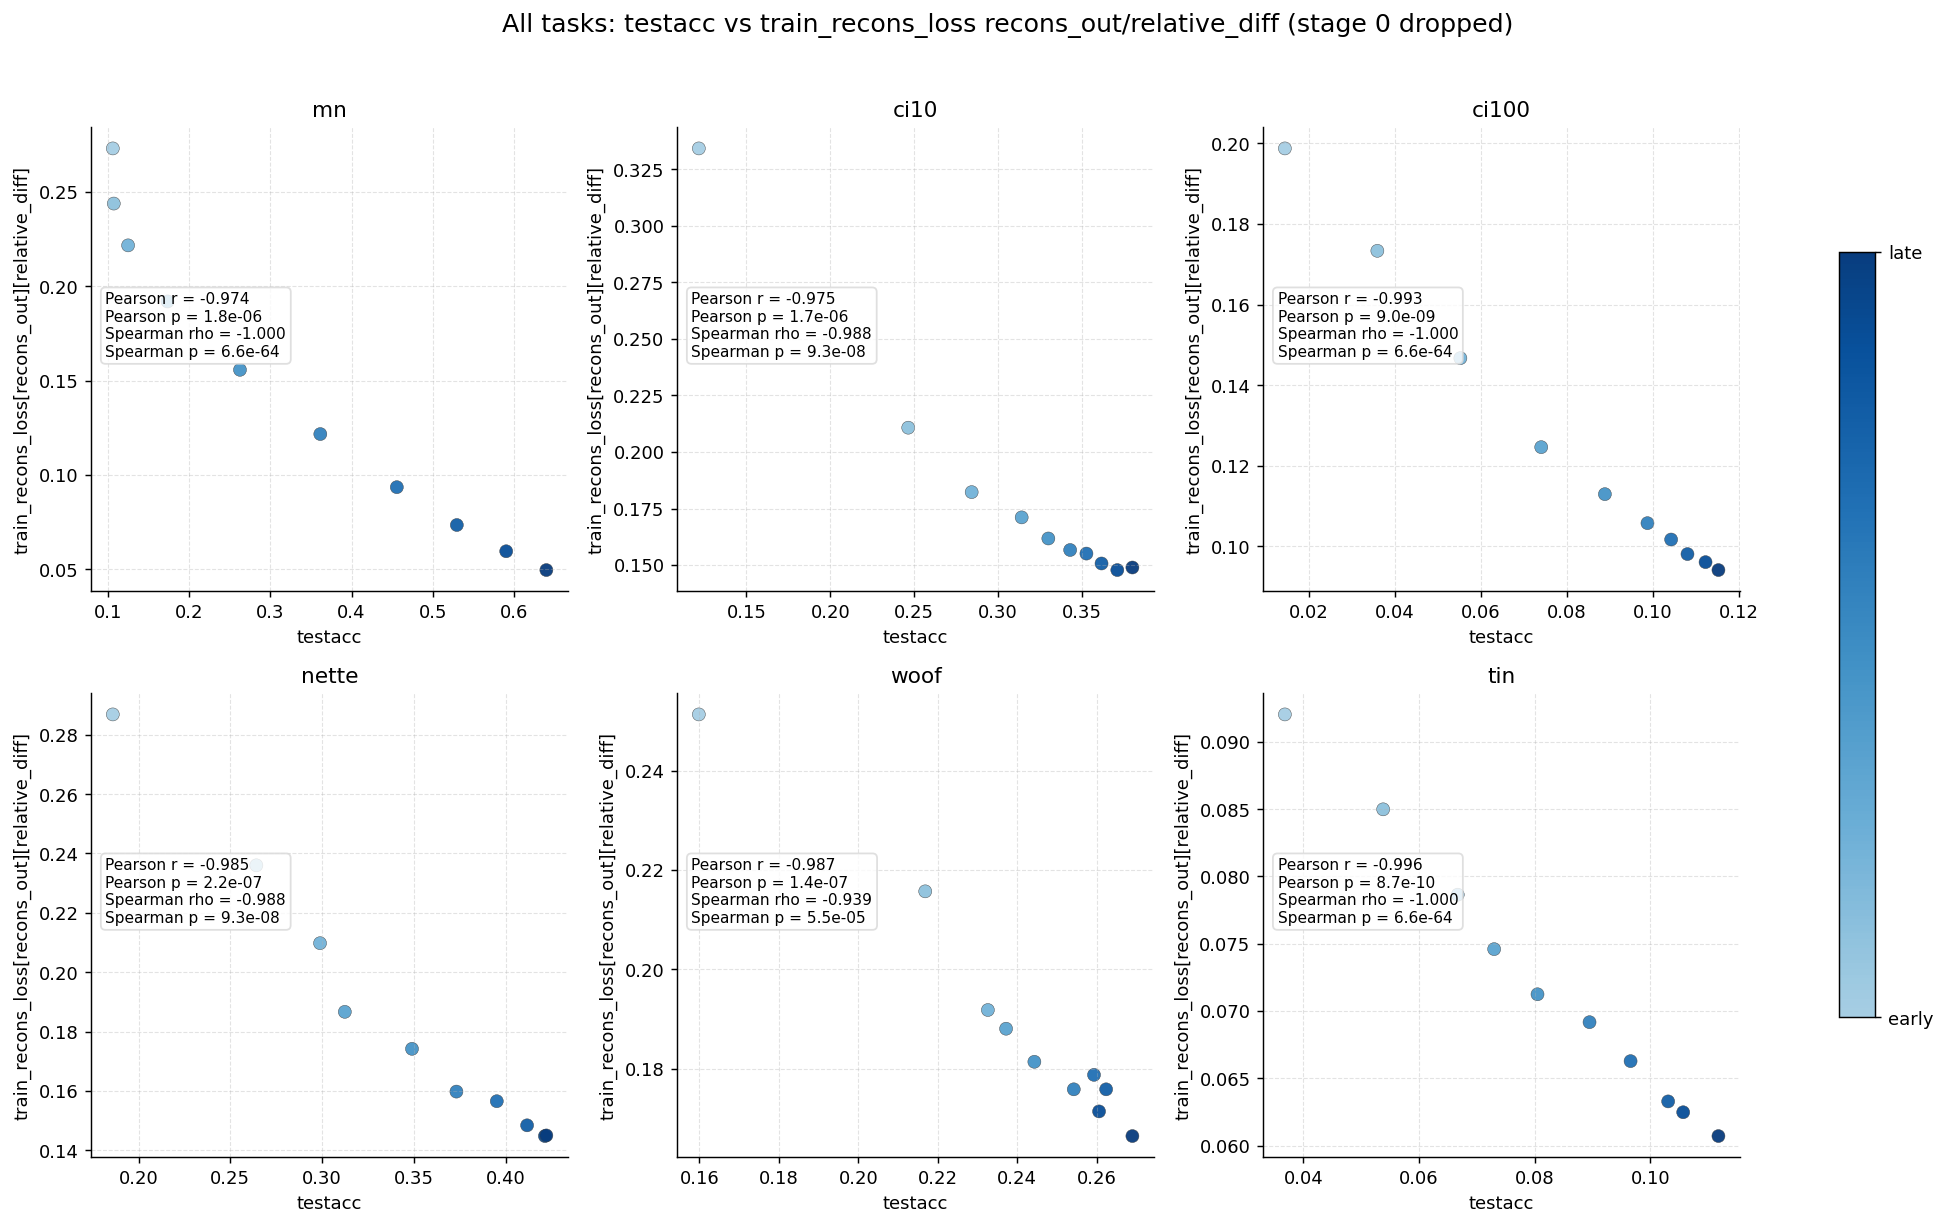

Saved figure to `/data/dn/FRTP_revision1/imagecls/logs_stage/all_tasks_train_recons_out_relative_diff.png` and statistics to `/data/dn/FRTP_revision1/imagecls/logs_stage/all_tasks_train_recons_out_relative_diff_stats.csv`.

,task,pearson_r,pearson_p,spearman_rho,spearman_p
0,mn,-0.974389,1.825173e-06,-1.000000,6.646897e-64
1,ci10,-0.974961,1.668586e-06,-0.987879,9.307460e-08
2,ci100,-0.993260,8.957295e-09,-1.000000,6.646897e-64
3,nette,-0.985004,2.172855e-07,-0.987879,9.307460e-08
4,woof,-0.986581,1.395917e-07,-0.939394,5.484053e-05
5,tin,-0.996241,8.695676e-10,-1.000000,6.646897e-64


In [5]:
"""在下面写代码,画6个数据集任务的所有recons_out的图,同样是metrics可以挑,其他配置都一样,就是只画recons_out的图"""

ALL_TASK_RECONS_METRICS = RECONS_METRICS
ALL_TASK_RECONS_KEY = "recons_out"
# Keep stage 0 here so every saved point is drawn for each task.
ALL_TASK_DROP_FIRST_STAGE = True
LOGS_STAGE_DIR = Path("/data/dn/FRTP_revision1/imagecls/logs_stage")
ALL_TASK_LOG_PATHS = [
    LOGS_STAGE_DIR / "mn_simplecnnv2_relu_1e-05lr.pt",
    LOGS_STAGE_DIR / "ci10_simplecnnv2_relu_1e-05lr.pt",
    LOGS_STAGE_DIR / "ci100_simplecnnv2_relu_1e-05lr.pt",
    LOGS_STAGE_DIR / "nette_simplecnnv2_relu_1e-05lr.pt",
    LOGS_STAGE_DIR / "woof_simplecnnv2_relu_1e-05lr.pt",
    LOGS_STAGE_DIR / "tin_simplecnnv2_relu_1e-05lr.pt",
]
ALL_TASK_FIG_PATH = LOGS_STAGE_DIR / f"all_tasks_{LOSS_SOURCE}_{ALL_TASK_RECONS_KEY}_{ALL_TASK_RECONS_METRICS}.png"
ALL_TASK_CSV_PATH = LOGS_STAGE_DIR / f"all_tasks_{LOSS_SOURCE}_{ALL_TASK_RECONS_KEY}_{ALL_TASK_RECONS_METRICS}_stats.csv"


def paired_xy_for_metric(log, recons_key, metric):
    x = as_float_array(log["test_score_list"])
    y = as_float_array(log[f"{LOSS_SOURCE}_recons_loss_list"][recons_key][metric])
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    if ALL_TASK_DROP_FIRST_STAGE:
        x, y = x[1:], y[1:]
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


ncols = 3
nrows = int(np.ceil(len(ALL_TASK_LOG_PATHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows), squeeze=False)
axes = axes.ravel()
all_task_rows = []
max_points = 0

for ax, task_log_path in zip(axes, ALL_TASK_LOG_PATHS):
    task_name = task_log_path.stem.split("_")[0]
    try:
        log = torch.load(task_log_path, map_location="cpu")
        loss_dict = log[f"{LOSS_SOURCE}_recons_loss_list"]
        if ALL_TASK_RECONS_KEY not in loss_dict:
            raise KeyError(f"missing {ALL_TASK_RECONS_KEY}")
        if ALL_TASK_RECONS_METRICS not in loss_dict[ALL_TASK_RECONS_KEY]:
            raise KeyError(f"missing metric {ALL_TASK_RECONS_METRICS}")

        x, y = paired_xy_for_metric(log, ALL_TASK_RECONS_KEY, ALL_TASK_RECONS_METRICS)
        max_points = max(max_points, len(x))
        x, y = x[:10], y[:10]
        st = correlation_stats(x, y)
        all_task_rows.append({
            "task": task_name,
            "model": str(log.get("model", task_log_path.stem)),
            "log_path": str(task_log_path),
            "loss_source": LOSS_SOURCE,
            "recons_key": ALL_TASK_RECONS_KEY,
            "metrics": ALL_TASK_RECONS_METRICS,
            "drop_first_stage": ALL_TASK_DROP_FIRST_STAGE,
            **st,
        })

        ax.scatter(x, y, s=52, alpha=0.95, color=stage_colors(len(x)), edgecolor="0.25", linewidth=0.25)

        stat_text = (
            f"Pearson r = {st['pearson_r']:.3f}\n"
            f"Pearson p = {p_text(st['pearson_p'])}\n"
            f"Spearman rho = {st['spearman_rho']:.3f}\n"
            f"Spearman p = {p_text(st['spearman_p'])}"
        )
        ax.text(
            0.03,
            0.5,
            stat_text,
            transform=ax.transAxes,
            va="bottom",
            ha="left",
            fontsize=8.5,
            bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.82, "edgecolor": "0.85"},
        )
    except Exception as exc:
        ax.text(0.5, 0.5, str(exc), transform=ax.transAxes, ha="center", va="center", wrap=True)
        all_task_rows.append({
            "task": task_name,
            "model": np.nan,
            "log_path": str(task_log_path),
            "loss_source": LOSS_SOURCE,
            "recons_key": ALL_TASK_RECONS_KEY,
            "metrics": ALL_TASK_RECONS_METRICS,
            "drop_first_stage": ALL_TASK_DROP_FIRST_STAGE,
            "error": str(exc),
        })

    ax.set_title(task_name, fontsize=12)
    ax.set_xlabel("testacc")
    ax.set_ylabel(f"{LOSS_SOURCE}_recons_loss[{ALL_TASK_RECONS_KEY}][{ALL_TASK_RECONS_METRICS}]")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

for ax in axes[len(ALL_TASK_LOG_PATHS):]:
    ax.axis("off")

fig.suptitle(
    f"All tasks: testacc vs {LOSS_SOURCE}_recons_loss {ALL_TASK_RECONS_KEY}/{ALL_TASK_RECONS_METRICS}"
    + (" (stage 0 dropped)" if ALL_TASK_DROP_FIRST_STAGE else ""),
    y=1.02,
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 0.88, 1])
if max_points:
    add_stage_colorbar(fig, max_points)
fig.savefig(ALL_TASK_FIG_PATH, bbox_inches="tight")

all_task_stats_df = pd.DataFrame(all_task_rows)
all_task_stats_df = all_task_stats_df[['task', 'pearson_r', 'pearson_p','spearman_rho', 'spearman_p']]
all_task_stats_df.to_csv(ALL_TASK_CSV_PATH, index=False)
plt.show()
display(Markdown(f"Saved figure to `{ALL_TASK_FIG_PATH}` and statistics to `{ALL_TASK_CSV_PATH}`."))
display(all_task_stats_df)
